<a href="https://colab.research.google.com/github/sbrgothub/chocolate_Sales/blob/main/Customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt

In [ ]:
sales=  pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/chocolate/sales.csv')
product=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/chocolate/products.csv')
customers=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/chocolate/customers.csv')
calendar=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/chocolate/calendar.csv')
store=pd.read_csv('/content/drive/MyDrive/luminar/data_science/resume/chocolate/stores.csv')

# Data Cleaning and preprocessing

In [ ]:
df=[sales,product,customers,calendar]
list(map(lambda x: x.isna().sum(),df)),list(map(lambda x: x.duplicated().sum(),df))

([order_id       0
  order_date     0
  product_id     0
  store_id       0
  customer_id    0
  quantity       0
  unit_price     0
  discount       0
  revenue        0
  cost           0
  profit         0
  dtype: int64,
  product_id       0
  product_name     0
  brand            0
  category         0
  cocoa_percent    0
  weight_g         0
  dtype: int64,
  customer_id       0
  age               0
  gender            0
  loyalty_member    0
  join_date         0
  dtype: int64,
  date           0
  year           0
  month          0
  day            0
  week           0
  day_of_week    0
  dtype: int64],
 [np.int64(0), np.int64(0), np.int64(0), np.int64(0)])

In [ ]:
calendar['order_date']=calendar['date']
calendar=calendar.drop(columns='date')

**Remove Unrecognized data from field table:**
>Since field table is derived from dimenstion table. all data in field table present in dimension table is must.

>All Field table datas not present in dimension table must be removed.

In [ ]:
pairs={'product_id':product,'customer_id':customers,'store_id':store,'order_date':calendar}

for column_name, lookup_df in pairs.items():

  sales_keys = set(sales[column_name])
  lookup_keys = set(lookup_df[column_name])

  orphan_keys = list(sales_keys.difference(lookup_keys))
  print(f"{column_name} {orphan_keys}")

  sales= sales[~sales[column_name].isin(orphan_keys)] if len(orphan_keys)>0 else sales
  print(f"removed {orphan_keys}")

product_id ['P0201', 'P0000']
removed ['P0201', 'P0000']
customer_id []
removed []
store_id []
removed []
order_date []
removed []


Check if revenue value is approximately equal to calculated revenue manually.(qty * unit_price) - discount

In [ ]:
sales['revenue']-sales['cost']
a=sales['unit_price']*sales['quantity']
c=a-a*sales['discount']
# math.isclose(c,sales['revenue'])
for j in sales.index:
  if math.isclose(sales[sales.index==j]['revenue'].values[0],c[c.index==j].values[0],rel_tol=0.5)==False:
    print(j)
  break

# Customer_Segmentation

RFM property of customers

In [ ]:
data=sales.copy()

In [ ]:
data.columns

Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit'],
      dtype='object')

In [ ]:
sales['order_date']=pd.to_datetime(sales['order_date'])

/tmp/ipykernel_7912/1316694316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['order_date']=pd.to_datetime(sales['order_date'])


In [ ]:
sales=sales.sort_values(by=['customer_id','order_date'])
sales

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
85015,0RD00085016,2023-01-31,P0030,S011,C000001,5,13.91,0.00,69.55,39.24,30.31
240389,0RD00240390,2023-01-31,P0019,S044,C000001,3,3.89,0.00,11.67,7.97,3.70
881353,0RD00881354,2023-02-09,P0146,S027,C000001,2,4.48,0.15,7.62,4.70,2.92
169881,0RD00169882,2023-02-12,P0004,S039,C000001,2,12.70,0.15,21.59,13.58,8.01
313599,0RD00313600,2023-05-07,P0175,S063,C000001,2,10.20,0.20,16.32,10.38,5.94
...,...,...,...,...,...,...,...,...,...,...,...
940127,0RD00940128,2024-09-04,P0030,S040,C050000,5,5.94,0.15,25.25,15.38,9.86
966041,0RD00966042,2024-10-22,P0140,S025,C050000,1,9.84,0.00,9.84,6.18,3.66
476719,0RD00476720,2024-10-31,P0128,S062,C050000,2,10.24,0.00,20.48,10.33,10.15
269675,0RD00269676,2024-11-15,P0020,S071,C050000,3,8.13,0.00,24.39,13.34,11.05


In [ ]:
data['recency']=data.groupby('customer_id')['order_date'].diff().dt.days

/tmp/ipykernel_7912/625558319.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['recency']=data.groupby('customer_id')['order_date'].diff().dt.days


In [ ]:
rfm=data.groupby('customer_id').agg(frequency=('customer_id','count'),
                                      age=('order_date',lambda x:(data['order_date'].max()-x.min()).days),
                                      monetary_revenue=('revenue','mean'),
                                      monetary_profit=('profit','mean'),
                                      recency=('recency','mean')).reset_index()

In [ ]:
rfm

,customer_id,frequency,age,monetary_revenue,monetary_profit,recency
0,C000001,25,700,19.246400,7.883200,28.125000
1,C000002,24,706,24.421250,10.541667,29.739130
2,C000003,24,719,28.265417,10.339167,29.304348
3,C000004,18,713,29.617222,12.019444,40.470588
4,C000005,32,723,25.347500,10.538438,22.967742
...,...,...,...,...,...,...
49995,C049996,20,668,26.784000,10.207000,35.157895
49996,C049997,15,580,33.363333,12.668000,40.142857
49997,C049998,21,720,27.441905,10.998095,35.100000
49998,C049999,14,666,25.430714,10.201429,47.846154


In [ ]:
x=rfm.iloc[:,1:]

In [ ]:
x

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mn=MinMaxScaler()
mn.fit_transform(x)

array([[0.57142857, 0.92555831, 0.23885718, 0.27308187, 0.07561008],
       [0.54285714, 0.94044665, 0.38972256, 0.46046462, 0.08707664],
       [0.54285714, 0.97270471, 0.50179375, 0.44619135, 0.083988  ],
       ...,
       [0.45714286, 0.9751861 , 0.47778544, 0.49263611, 0.12515951],
       [0.25714286, 0.84119107, 0.41915205, 0.43648284, 0.21570641],
       [0.48571429, 0.96526055, 0.46210624, 0.4748607 , 0.10449066]])

Find Optimal Cluster

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
n_clusters=range(1,36)
wcss=[]
for i in n_clusters:
  cluster=KMeans(n_clusters=i,random_state=1)
  cluster.fit(x)
  wcss.append(cluster.inertia_)

([<matplotlib.axis.XTick at 0x7b75adf9bf50>,
 [Text(0, 0, '0'),
  Text(2, 0, '2'),
  Text(4, 0, '4'),
  Text(6, 0, '6'),
  Text(8, 0, '8'),
  Text(10, 0, '10'),
  Text(12, 0, '12'),
  Text(14, 0, '14'),
  Text(16, 0, '16'),
  Text(18, 0, '18'),
  Text(20, 0, '20'),
  Text(22, 0, '22'),
  Text(24, 0, '24'),
  Text(26, 0, '26'),
  Text(28, 0, '28'),
  Text(30, 0, '30'),
  Text(32, 0, '32'),
  Text(34, 0, '34'),
  Text(36, 0, '36')])

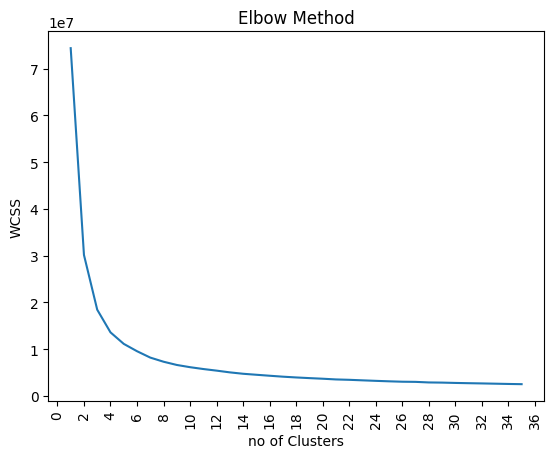

In [ ]:
plt.title('Elbow Method')
plt.xlabel('no of Clusters')
plt.ylabel('WCSS')
plt.plot(n_clusters,wcss)
plt.xticks(range(0,37,2),rotation=90)

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
for j in range(2,12):
  optimal_cluster_1=KMeans(n_clusters=j,random_state=1)
  optimal_cluster_1.fit(x)
  print(j,silhouette_score(x,optimal_cluster_1.labels_))

2 0.6083175216166071
3 0.5073688378842701
4 0.4352840171637358
5 0.39411767004257797
6 0.3443154479161209


KeyboardInterrupt: 

In [ ]:
for j in range(9,1):
  optimal_cluster_1=KMeans(n_clusters=j,random_state=1)
  optimal_cluster_1.fit(x)
  print(j,silhouette_score(x,optimal_cluster_1.labels_))

In [ ]:
optimal_cluster_1=KMeans(n_clusters=7,random_state=1)
optimal_cluster_1.fit(x)

# print(j,silhouette_score(x,optimal_cluster_1.labels_))

KMeans(n_clusters=7, random_state=1)

In [ ]:
optimal_cluster_2=KMeans(n_clusters=8,random_state=1)
optimal_cluster_2.fit(x)

KMeans(random_state=1)

In [ ]:
print(silhouette_score(x,optimal_cluster_1.labels_))
print(silhouette_score(x,optimal_cluster_2.labels_))

0.3431634702590482
0.3289480698200261


In [ ]:
for j in range(9,12):
  optimal_cluster_1=KMeans(n_clusters=j,random_state=1)
  optimal_cluster_1.fit(x)
  print(j,silhouette_score(x,optimal_cluster_1.labels_))

9 0.32551911410285994
10 0.3095724012785957
11 0.30672916863481975


In [ ]:
optimal_cluster=KMeans(n_clusters=4,random_state=1)
optimal_cluster.fit(x)

KMeans(n_clusters=4, random_state=1)

In [ ]:
rfm['group']=optimal_cluster.labels_